# The Rosetta Invariant — Companion Notebook
## A computational companion to **_The Rosetta Invariant: A Lithic Map of the Universal Ground Plane_**

This notebook is built to accompany the paper as a **working mathematical instrument**.

It stays in the paper's computational spine and verifies the core claims that are naturally testable in code:

- prime-root voltage rails \(H_0\) and \(K\),
- the round-0 ground plane
  \[
  T2^{(0)}_0 = 0x08909ae5,
  \]
- the 64-round message-free NOP backbone,
- the dual-seam topology of the die,
- orthogonal injection into the two active heads,
- subtracting the ground to reveal displacement,
- coarse closure metrics and the post-closure density band.

This notebook does **not** try to simulate semiconductor physics directly.  
Instead, it treats the transistor/domain mapping as a **triadic closure reading** of the computational object and keeps the code in the most resolute domain: explicit state-transition machinery.


## Notebook map

### Section A — Setup
Utilities, bit operators, and prime-root constant generation.

### Section B — Universal rails
Derive \(H_0\) from square roots of the first eight primes and \(K\) from cube roots of the first 64 primes.

### Section C — Ground plane
Verify
\[
T2^{(0)}_0 = \Sigma_0(H_0[0]) + \operatorname{Maj}(H_0[0],H_0[1],H_0[2]) = 0x08909ae5.
\]

### Section D — NOP backbone
Run the 64-round die with \(W_r=0\) and inspect the early rounds.

### Section E — Dual seams / orthogonal injection
Formalize the two active heads \(a\) and \(e\), the passive shift lanes, and the word-support diameter.

### Section F — Glass-key subtraction
Inject one-hot perturbations at \(W_0\), subtract the NOP backbone, and inspect the residue trace.

### Section G — Closure observables
Compute the age-class means, lane variance, lane range, and global density band.

### Section H — ISA extraction
Summarize the minimal and derived instruction sets.

Everything is parameterized at the top so you can bend the notebook without rewriting it.


In [1]:
# --- Configuration ---
DISPLAY_ROUNDS = 10            # how many early NOP rounds to display
SAMPLE_W0 = 0x00000001         # example perturbation for the Glass-Key cells
RUN_FULL_ONE_HOT_SCAN = True   # compute all 32 one-hot perturbations
MAX_SCAN_ROUNDS = 64           # full die depth

# plotting
MAKE_DENSITY_PLOT = True


In [2]:
# --- Imports ---
from decimal import Decimal, getcontext
from statistics import mean
import math

import pandas as pd
import matplotlib.pyplot as plt

MASK = 0xFFFFFFFF
getcontext().prec = 120


In [3]:
# --- Number-theoretic utilities ---
def first_primes(n: int):
    out = []
    x = 2
    while len(out) < n:
        is_prime = True
        for p in out:
            if p * p > x:
                break
            if x % p == 0:
                is_prime = False
                break
        if is_prime:
            out.append(x)
        x += 1
    return out

def dec_cuberoot(n: int) -> Decimal:
    n = Decimal(n)
    x = n
    for _ in range(100):
        prev = x
        x = (2 * x + n / (x * x)) / 3
        if abs(x - prev) < Decimal(1) / (10 ** 100):
            break
    return +x

def frac_u32(x: Decimal) -> int:
    frac = x - int(x)
    return int(frac * (1 << 32))

def hex32(x: int) -> str:
    return f"0x{x & MASK:08x}"


In [4]:
# --- Bitwise primitives ---
def rotr(x: int, n: int) -> int:
    return ((x >> n) | ((x << (32 - n)) & MASK)) & MASK

def shr(x: int, n: int) -> int:
    return (x >> n) & MASK

def BSIG0(x: int) -> int:
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def BSIG1(x: int) -> int:
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def SSIG0(x: int) -> int:
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def SSIG1(x: int) -> int:
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def Ch(e: int, f: int, g: int) -> int:
    return ((e & f) ^ ((~e) & g)) & MASK

def Maj(a: int, b: int, c: int) -> int:
    return ((a & b) ^ (a & c) ^ (b & c)) & MASK

def wt32(x: int) -> int:
    return (x & MASK).bit_count()


## Section B — Universal rails

The paper ties the universal substrate to three fixed computational rails:

- \(H_0\): the power supply, derived from the fractional parts of the square roots of the first eight primes,
- \(K\): the non-repeating clock, derived from the fractional parts of the cube roots of the first 64 primes,
- \(T2\): the message-free ground fold.

The first two are directly computable.


In [5]:
# --- Derive H0 and K from prime roots ---
PRIMES_8 = first_primes(8)
PRIMES_64 = first_primes(64)

H0 = [frac_u32(Decimal(p).sqrt()) for p in PRIMES_8]
K = [frac_u32(dec_cuberoot(p)) for p in PRIMES_64]

H0_df = pd.DataFrame({
    "prime": PRIMES_8,
    "sqrt(prime)_frac_u32": [hex32(x) for x in H0],
})
K_df = pd.DataFrame({
    "prime": PRIMES_64[:8],
    "cuberoot(prime)_frac_u32": [hex32(x) for x in K[:8]],
})

print("H0 rails:")
display(H0_df)

print("First 8 K pulses:")
display(K_df)


H0 rails:


,prime,sqrt(prime)_frac_u32
0,2,0x6a09e667
1,3,0xbb67ae85
2,5,0x3c6ef372
3,7,0xa54ff53a
4,11,0x510e527f
5,13,0x9b05688c
6,17,0x1f83d9ab
7,19,0x5be0cd19


First 8 K pulses:


,prime,cuberoot(prime)_frac_u32
0,2,0x428a2f98
1,3,0x71374491
2,5,0xb5c0fbcf
3,7,0xe9b5dba5
4,11,0x3956c25b
5,13,0x59f111f1
6,17,0x923f82a4
7,19,0xab1c5ed5


## Section C — Ground plane

The message-free round-0 fold is

\[
T2^{(0)}_0 = \Sigma_0(H_0[0]) + \operatorname{Maj}(H_0[0],H_0[1],H_0[2]) \pmod{2^{32}}.
\]

The paper identifies the value

\[
0x08909ae5
\]

as the absolute floor / NOP ground plane. This cell verifies it directly.


In [6]:
# --- Verify the round-0 ground plane ---
T2_ground = (BSIG0(H0[0]) + Maj(H0[0], H0[1], H0[2])) & MASK
print("T2_0^(NOP) =", hex32(T2_ground))
assert T2_ground == 0x08909AE5


T2_0^(NOP) = 0x08909ae5


In [7]:
# --- Round function and NOP backbone ---
def round_step(state, k_word, w_word):
    a, b, c, d, e, f, g, h = state
    t1 = (h + BSIG1(e) + Ch(e, f, g) + k_word + w_word) & MASK
    t2 = (BSIG0(a) + Maj(a, b, c)) & MASK
    new_state = [
        (t1 + t2) & MASK,
        a, b, c,
        (d + t1) & MASK,
        e, f, g,
    ]
    return new_state, t1, t2

def nop_backbone(rounds=64):
    state = H0[:]
    rows = []
    for r in range(rounds):
        state, t1, t2 = round_step(state, K[r], 0)
        rows.append({
            "round": r + 1,
            "a": hex32(state[0]),
            "b": hex32(state[1]),
            "c": hex32(state[2]),
            "d": hex32(state[3]),
            "e": hex32(state[4]),
            "f": hex32(state[5]),
            "g": hex32(state[6]),
            "h": hex32(state[7]),
            "T1": hex32(t1),
            "T2": hex32(t2),
        })
    return rows

nop_rows = nop_backbone(64)
nop_df = pd.DataFrame(nop_rows)
display(nop_df.head(DISPLAY_ROUNDS))


,round,a,b,c,d,e,f,g,h,T1,T2
0,1,0xfc08884d,0x6a09e667,0xbb67ae85,0x3c6ef372,0x98c7e2a2,0x510e527f,0x9b05688c,0x1f83d9ab,0xf377ed68,0x08909ae5
1,2,0x7ad96290,0xfc08884d,0x6a09e667,0xbb67ae85,0x9df1b216,0x98c7e2a2,0x510e527f,0x9b05688c,0x6182bea4,0x1956a3ec
2,3,0xf3dd6c3f,0x7ad96290,0xfc08884d,0x6a09e667,0xc57b68fb,0x9df1b216,0x98c7e2a2,0x510e527f,0x0a13ba76,0xe9c9b1c9
3,4,0x0a24b1aa,0xf3dd6c3f,0x7ad96290,0xfc08884d,0x909cf5c9,0xc57b68fb,0x9df1b216,0x98c7e2a2,0x26930f62,0xe391a248
4,5,0x489fc27e,0x0a24b1aa,0xf3dd6c3f,0x7ad96290,0x2cab14aa,0x909cf5c9,0xc57b68fb,0x9df1b216,0x30a28c5d,0x17fd3621
5,6,0x6bb2da87,0x489fc27e,0x0a24b1aa,0xf3dd6c3f,0x9d120f96,0x2cab14aa,0x909cf5c9,0xc57b68fb,0x2238ad06,0x497a2d81
6,7,0x965ecae2,0x6bb2da87,0x489fc27e,0x0a24b1aa,0x79c76dda,0x9d120f96,0x2cab14aa,0x909cf5c9,0x85ea019b,0x1074c947
7,8,0x5e498fb3,0x965ecae2,0x6bb2da87,0x489fc27e,0x9426ec60,0x79c76dda,0x9d120f96,0x2cab14aa,0x8a023ab6,0xd44754fd
8,9,0x258e85ba,0x5e498fb3,0x965ecae2,0x6bb2da87,0x839d20bc,0x9426ec60,0x79c76dda,0x9d120f96,0x3afd5e3e,0xea91277c
9,10,0x87dd269e,0x258e85ba,0x5e498fb3,0x965ecae2,0x3e9d0be7,0x839d20bc,0x9426ec60,0x79c76dda,0xd2ea3160,0xb4f2f53e


## Section D — Dual seams / triadic closure reading

The computational object has two active heads and six passive transport lanes.

### Active seams
\[
a_{r+1} = T1_r + T2_r
\]
\[
e_{r+1} = d_r + T1_r
\]

### Passive shifts
\[
b_{r+1}=a_r,\quad c_{r+1}=b_r,\quad d_{r+1}=c_r
\]
\[
f_{r+1}=e_r,\quad g_{r+1}=f_r,\quad h_{r+1}=g_r
\]

This is the computational spine underneath the paper's transistor reading:

- one central coincidence chamber,
- two live seams,
- one orthogonal permission event at injection,
- six lanes that preserve transport history.

The next cell computes the coarse support matrix \(M\) and verifies the word-support diameter.


In [8]:
# --- Word-support transport ---
lane_names = ["a", "b", "c", "d", "e", "f", "g", "h"]

M = [
    [1,1,1,0,1,1,1,1],  # a' depends on a,b,c,e,f,g,h
    [1,0,0,0,0,0,0,0],  # b' <- a
    [0,1,0,0,0,0,0,0],  # c' <- b
    [0,0,1,0,0,0,0,0],  # d' <- c
    [0,0,0,1,1,1,1,1],  # e' depends on d,e,f,g,h
    [0,0,0,0,1,0,0,0],  # f' <- e
    [0,0,0,0,0,1,0,0],  # g' <- f
    [0,0,0,0,0,0,1,0],  # h' <- g
]
b_inj = [1,0,0,0,1,0,0,0]

def bool_matvec(M, v):
    out = []
    for row in M:
        hit = 0
        for a, b in zip(row, v):
            if a and b:
                hit = 1
                break
        out.append(hit)
    return out

supports = []
v = b_inj[:]
for step in range(1, 6):
    supports.append({"step": step, **{lane: bit for lane, bit in zip(lane_names, v)}})
    v = bool_matvec(M, v)

support_df = pd.DataFrame(supports)
display(support_df)

D_word = next(
    row["step"] for _, row in support_df.iterrows()
    if all(row[lane] == 1 for lane in lane_names)
)
print("D_word =", D_word)


,step,a,b,c,d,e,f,g,h
0,1,1,0,0,0,1,0,0,0
1,2,1,1,0,0,1,1,0,0
2,3,1,1,1,0,1,1,1,0
3,4,1,1,1,1,1,1,1,1
4,5,1,1,1,1,1,1,1,1


D_word = 4


## Section E — Glass-Key subtraction

The paper's computational claim can be written cleanly:

- there is an eternal tape,
- there is a displaced tape,
- subtracting the NOP backbone reveals the residue trace.

At round 0:

\[
T1_{\text{real},0} = T1_{\text{nop},0} + W_0,
\]

so

\[
\delta T1_0 = W_0,
\qquad
\delta a_1 = \delta e_1 = W_0.
\]

The next cell verifies that identity for a sample one-hot injection.


In [9]:
# --- Verify delta T1_0 = W0 and delta x1 on a sample perturbation ---
state0 = H0[:]
nop_state1, nop_t1_0, nop_t2_0 = round_step(state0, K[0], 0)
real_state1, real_t1_0, real_t2_0 = round_step(state0, K[0], SAMPLE_W0)

delta_t1_0 = (real_t1_0 - nop_t1_0) & MASK
delta_state1 = [(r - n) & MASK for r, n in zip(real_state1, nop_state1)]

print("W0 sample       :", hex32(SAMPLE_W0))
print("delta T1_0      :", hex32(delta_t1_0))
print("delta state[1]  :", [hex32(x) for x in delta_state1])
assert delta_t1_0 == SAMPLE_W0
assert delta_state1[0] == SAMPLE_W0 and delta_state1[4] == SAMPLE_W0


W0 sample       : 0x00000001
delta T1_0      : 0x00000001
delta state[1]  : ['0x00000001', '0x00000000', '0x00000000', '0x00000000', '0x00000001', '0x00000000', '0x00000000', '0x00000000']


In [10]:
# --- One-hot perturbation scan through the die ---
def run_local_die_with_w0(w0: int, rounds: int = 64):
    state = H0[:]
    out = []
    for r in range(rounds):
        w = w0 if r == 0 else 0
        state, t1, t2 = round_step(state, K[r], w)
        out.append(state[:])
    return out

def xor_weights_against_nop(rounds=64):
    nop_states = [H0[:]]
    state = H0[:]
    for r in range(rounds):
        state, _, _ = round_step(state, K[r], 0)
        nop_states.append(state[:])

    all_runs = {}
    for j in range(32):
        w0 = 1 << j
        state = H0[:]
        rows = []
        for r in range(rounds):
            w = w0 if r == 0 else 0
            state, _, _ = round_step(state, K[r], w)
            delta = [(s ^ n) & MASK for s, n in zip(state, nop_states[r + 1])]
            rows.append(delta)
        all_runs[j] = rows
    return nop_states, all_runs

nop_states, one_hot_runs = xor_weights_against_nop(MAX_SCAN_ROUNDS)
print("Computed one-hot perturbation runs:", len(one_hot_runs))


Computed one-hot perturbation runs: 32


## Section F — Closure observables

We now measure four observables from the displaced-vs-NOP difference field:

### Global mean density
\[
\bar\mu(r)
\]

### Age-class spread
\[
\mathcal E_{\mathrm{age}}(r)
\]

### Lane variance
\[
\mathcal V(r)
\]

### Lane range
\[
\mathcal R(r)
\]

These are the notebook forms of the paper's closure / scar / residual-smoothing claims.


In [11]:
# --- Closure observables from one-hot runs ---
def lane_means(round_index):
    # round_index is 1-based in the notebook discussion
    idx = round_index - 1
    means = []
    for lane in range(8):
        vals = [wt32(one_hot_runs[j][idx][lane]) for j in range(32)]
        means.append(sum(vals) / len(vals))
    return means

def closure_metrics(round_index):
    mu = lane_means(round_index)
    mu_bar = sum(mu) / 8.0

    mu_H = (mu[0] + mu[4]) / 2.0
    mu_M = (mu[1] + mu[2] + mu[5] + mu[6]) / 4.0
    mu_T = (mu[3] + mu[7]) / 2.0

    E_age = max(mu_H, mu_M, mu_T) - min(mu_H, mu_M, mu_T)
    V = sum((x - mu_bar) ** 2 for x in mu) / 8.0
    R = max(mu) - min(mu)

    return {
        "round": round_index,
        "mu_bar": mu_bar,
        "mu_H": mu_H,
        "mu_M": mu_M,
        "mu_T": mu_T,
        "E_age": E_age,
        "V": V,
        "R": R,
    }

metrics_df = pd.DataFrame([closure_metrics(r) for r in range(1, MAX_SCAN_ROUNDS + 1)])
display(metrics_df.loc[metrics_df["round"].isin([4,5,6,7,8,10])].reset_index(drop=True))


,round,mu_bar,mu_H,mu_M,mu_T,E_age,V,R
0,4,10.859375,15.734375,12.929688,1.843750,13.890625,33.672852,15.21875
1,5,14.367188,15.875000,15.734375,10.125000,5.750000,7.357361,8.78125
2,6,15.781250,15.781250,15.804688,15.734375,0.070312,0.409424,2.40625
3,7,15.816406,15.875000,15.828125,15.734375,0.140625,0.127060,1.12500
4,8,15.875000,15.968750,15.828125,15.875000,0.140625,0.147461,1.12500
5,10,15.902344,15.890625,15.921875,15.875000,0.046875,0.150986,1.12500


Post-closure density band:
  min(mu_bar) = 15.60546875 at round 22
  max(mu_bar) = 16.53125 at round 53


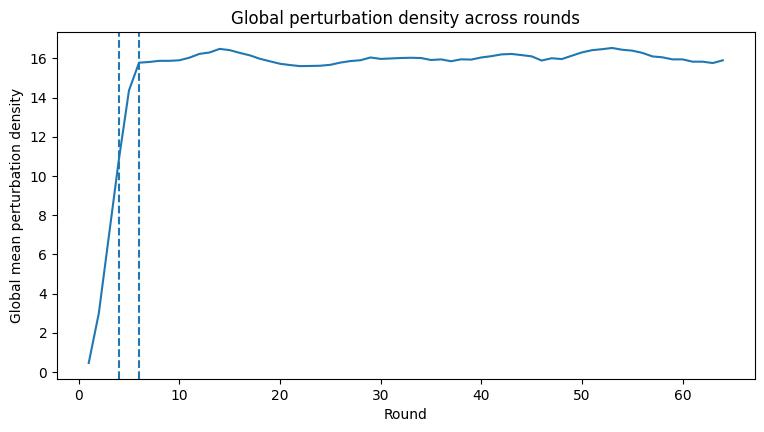

In [12]:
# --- Density band summary after support closure ---
post = metrics_df[metrics_df["round"] >= 6].copy()
mu_min = post["mu_bar"].min()
mu_max = post["mu_bar"].max()
r_min = int(post.loc[post["mu_bar"].idxmin(), "round"])
r_max = int(post.loc[post["mu_bar"].idxmax(), "round"])

print("Post-closure density band:")
print("  min(mu_bar) =", mu_min, "at round", r_min)
print("  max(mu_bar) =", mu_max, "at round", r_max)

if MAKE_DENSITY_PLOT:
    plt.figure(figsize=(9, 4.5))
    plt.plot(metrics_df["round"], metrics_df["mu_bar"])
    plt.axvline(4, linestyle="--")
    plt.axvline(6, linestyle="--")
    plt.xlabel("Round")
    plt.ylabel("Global mean perturbation density")
    plt.title("Global perturbation density across rounds")
    plt.show()


## Section G — ISA extraction

The minimal scalar instruction basis needed to generate the machine is

\[
\mathfrak I_{\min}
=
\{
\operatorname{ROTR},\ \operatorname{SHR},\ \oplus,\ \wedge,\ \neg,\ +_{32},\ \mathrm{MOV},\ \mathrm{LOAD}
\}.
\]

From that, the derived SHA macros are

\[
\mathfrak I_{\mathrm{SHA}}
=
\{
\mathrm{SSIG0},\mathrm{SSIG1},\mathrm{BSIG0},\mathrm{BSIG1},
\mathrm{CH},\mathrm{MAJ},
\mathrm{ROUND},\mathrm{SCHED},\mathrm{FEED}
\}.
\]

This notebook does not need to choose between hardware metaphor and math object.  
It simply shows that the computational substrate is already explicit enough to expose:

- rails,
- clock,
- ground,
- injection,
- closure,
- scar.


In [13]:
# --- ISA summary objects ---
ISA_min = [
    "ROTR_n",
    "SHR_n",
    "XOR",
    "AND",
    "NOT",
    "ADD_mod_2^32",
    "MOV",
    "LOAD",
]

ISA_sha = [
    "SSIG0",
    "SSIG1",
    "BSIG0",
    "BSIG1",
    "CH",
    "MAJ",
    "SCHED",
    "ROUND",
    "FEED",
]

print("Minimal ISA:")
for op in ISA_min:
    print(" -", op)

print("\nDerived SHA ISA:")
for op in ISA_sha:
    print(" -", op)


Minimal ISA:
 - ROTR_n
 - SHR_n
 - XOR
 - AND
 - NOT
 - ADD_mod_2^32
 - MOV
 - LOAD

Derived SHA ISA:
 - SSIG0
 - SSIG1
 - BSIG0
 - BSIG1
 - CH
 - MAJ
 - SCHED
 - ROUND
 - FEED


## Section H — Working conclusion

This notebook closes the paper's computational loop in the most explicit domain available.

The verified computational spine is:

\[
H_0 \to K \to T2^{(0)}_0 \to \Phi_r \to \text{NOP backbone} \to \text{displacement} \to \text{closure band}.
\]

The practical takeaways are:

1. the rails are derivable,
2. the ground plane is exact,
3. the dual seams are explicit,
4. the perturbation is first visible as a clean subtraction against the NOP backbone,
5. closure is a **banded** phenomenon rather than a single scalar endpoint.

This is the notebook form of the paper's central claim: the route is prior, the field is already there, and the visible object is a stable scar left by lawful traversal.
